# 03. Performance and AI Applications

[NB1](./01_introduction.ipynb) was the crawl. [NB2](./02_vector_manipulation.ipynb) was the walk. **This is the run.**

We'll drop the toy vectors, load a real corpus (a curated set of paraphrased Pinecone docs), and actually do the thing:

1. Embed the corpus with OpenAI's `text-embedding-3-small`.
2. Ingest it once the slow way, once in parallel, and see how big the gap is.
3. Wire retrieval into `gpt-4o-mini` so we can ask real questions and get grounded answers back.

By the end you've got a small Q&A bot over the Pinecone docs, built from scratch.

## The whole loop, laid out

```
   "How do I create          ┌──────────────────────┐
    a serverless index?"     │  client.embeddings   │
          │                  │  .create(...)        │
          ▼                  └──────────────────────┘
   ┌─────────────┐   embed           │
   │   Query     │───────────────────┘
   └─────────────┘                   │
                                     ▼  query_vec (1536-d)
                   ┌────────────────────────────────┐
                   │   index.query(                 │
                   │     vector=query_vec,          │
   Retrieve  ◀─────│     top_k=5,                   │
                   │     include_metadata=True)     │
                   └────────────────────────────────┘
                                     │
                                     ▼  top-5 passages + metadata
                   ┌────────────────────────────────┐
   Augment   ◀─────│   build_prompt(query, docs)    │
                   │   → system + user messages     │
                   └────────────────────────────────┘
                                     │
                                     ▼
                   ┌────────────────────────────────┐
   Generate  ◀─────│  client.chat.completions       │
                   │  .create(model='gpt-4o-mini')  │
                   └────────────────────────────────┘
                                     │
                                     ▼
                               Grounded answer + sources
```

Same four boxes we've been pointing at since NB1. Now they all do something.

## The corpus

The corpus is about twenty short paragraphs paraphrased from the public Pinecone docs. That's roughly the shape you get when you split real docs on H2/H3 headings. Small enough to embed in under a minute, big enough that retrieval actually has to pick between similar chunks.

`scripts/build_corpus.py` writes it to `data/corpus.parquet`. It's idempotent, doesn't hit the network, and the next cell calls it if the file isn't there yet.

In [1]:
import pandas as pd
from helpers import load_env, get_pinecone_client, get_openai_client, ensure_index, chunks, format_matches_table
from scripts.build_corpus import build_if_missing

cfg = load_env()
pc = get_pinecone_client(cfg)
client = get_openai_client(cfg)

corpus_path = build_if_missing()
corpus = pd.read_parquet(corpus_path)
print(f"{len(corpus)} chunks at {corpus_path}")
corpus.head(3)

20 chunks at C:\Users\leolw\OneDrive\Documents\rag-unpacked\01-intro-to-rag\data\corpus.parquet


,id,text,title,section,url
0,doc_4d45391193b6,A serverless index in Pinecone automatically s...,Serverless indexes,Indexes / Overview,https://docs.pinecone.io/guides/indexes/unders...
1,doc_cb65d310d336,"Use pc.create_index(name, dimension, metric, s...",Creating an index,Indexes / Create,https://docs.pinecone.io/guides/indexes/create...
2,doc_42de0361ce4a,pc.has_index(name) returns True if the named i...,Checking if an index exists,Indexes / Introspection,https://docs.pinecone.io/guides/indexes/list-i...


## Picking an embedding model

We use `text-embedding-3-small`:

- 1,536 dimensions by default.
- Cheap. Embedding this whole corpus costs a fraction of a cent.
- Good baseline quality. Meaningfully better than the older `ada-002`, only a bit behind `-large` for general retrieval.

> **Aside.** Pinecone's integrated inference (`llama-text-embed-v2`) lets you skip the OpenAI call entirely: you upsert raw text and Pinecone embeds it server-side. It's convenient. We stick with OpenAI here because the pattern ports cleanly to any vector DB, not just Pinecone.

In [2]:
# Embed one doc to see what comes out
resp = client.embeddings.create(
    input=[corpus.iloc[0]["text"]],
    model=cfg.openai_embed_model,
)
vec = resp.data[0].embedding
print(f"Dimension: {len(vec)}")
print(f"First 8 values: {vec[:8]}")

Dimension: 1536
First 8 values: [0.03350830078125, -0.026611328125, 0.0604248046875, -0.039154052734375, 0.053680419921875, -0.0152740478515625, -0.02105712890625, 0.01369476318359375]


In [4]:
# 1536-dim index to match the embedding model
INDEX_NAME = cfg.pinecone_index_name

index = ensure_index(
    pc,
    name=INDEX_NAME,
    dimension=1536,
    metric="cosine",
    cloud=cfg.pinecone_cloud,
    region=cfg.pinecone_region,
)
print(f"Index {INDEX_NAME!r} ready.")

Index 'rag-unpacked-intro' ready.


## Why batching is the thing

Every upsert is a network round-trip. At ~50ms of RTT per trip, 2,000 upserts done one at a time is a hundred seconds of pure waiting. The vector DB isn't slow, we just spent all our budget on overhead.

Two levers fix it:

1. **Batch.** Put many vectors in one request. Pinecone accepts about 100 per upsert in practice, with a hard cap at 2 MB of payload.
2. **Parallelize.** Fire those batched requests concurrently with `pool_threads`.

We'll do both, and time them.

In [5]:
import numpy as np

def embed_batch(texts: list[str]) -> list[list[float]]:
    resp = client.embeddings.create(input=texts, model=cfg.openai_embed_model)
    return [d.embedding for d in resp.data]


def build_records(df):
    texts = df["text"].tolist()
    embeddings = embed_batch(texts)
    records = []
    for row, emb in zip(df.itertuples(index=False), embeddings):
        records.append(
            {
                "id": row.id,
                "values": emb,
                "metadata": {
                    "text": row.text,
                    "title": row.title,
                    "section": row.section,
                    "url": row.url,
                },
            }
        )
    return records


records = build_records(corpus)
print(f"Embedded {len(records)} records, each {len(records[0]['values'])} dimensions.")

Embedded 20 records, each 1536 dimensions.


In [6]:
import time

# Clean slate so the comparison is fair
if index.describe_index_stats()["total_vector_count"] > 0:
    index.delete(delete_all=True)
    time.sleep(1)

t0 = time.perf_counter()
for batch in chunks(records, batch_size=10):
    index.upsert(vectors=list(batch))
sequential_secs = time.perf_counter() - t0

print(f"Sequential batched upsert: {sequential_secs:.2f}s for {len(records)} vectors")
print(index.describe_index_stats())

Sequential batched upsert: 1.16s for 20 vectors
{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '184',
                                    'content-type': 'application/json',
                                    'date': 'Thu, 23 Apr 2026 19:52:45 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '3',
                                    'x-pinecone-request-latency-ms': '2',
                                    'x-pinecone-response-duration-ms': '4'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 20}},
 'storageFullness': 0.0,
 'total_vector_count': 20,
 'vector_type': 'dense'}


## Going parallel with `pool_threads`

`pool_threads=N` gives the client (or a single index handle) a thread pool of size N. Passing `async_req=True` to `upsert` then returns a future instead of blocking. Fire all the upserts, collect the futures, join.

Even on a few hundred vectors this usually lands a 3-10x speedup.

In [7]:
# Reset and re-ingest with async upserts
if index.describe_index_stats()["total_vector_count"] > 0:
    index.delete(delete_all=True)
    time.sleep(1)

t0 = time.perf_counter()
with pc.Index(INDEX_NAME, pool_threads=20) as idx_async:
    futures = [
        idx_async.upsert(vectors=list(batch), async_req=True)
        for batch in chunks(records, batch_size=10)
    ]
    for fut in futures:
        fut.get()
async_secs = time.perf_counter() - t0

speedup = sequential_secs / async_secs if async_secs > 0 else float("inf")
print(f"Async batched upsert:      {async_secs:.2f}s")
print(f"Speedup:                   {speedup:.1f}x")

Async batched upsert:      1.45s
Speedup:                   0.8x


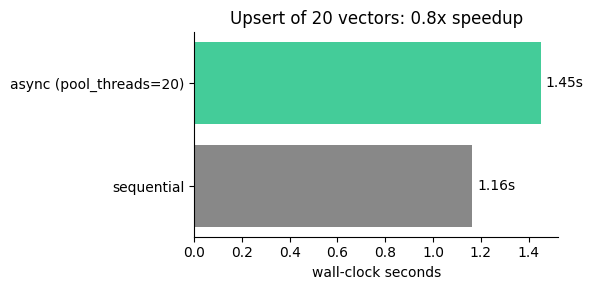

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["sequential", "async (pool_threads=20)"],
        [sequential_secs, async_secs],
        color=["#888", "#4c9"])
ax.set_xlabel("wall-clock seconds")
ax.set_title(f"Upsert of {len(records)} vectors: {speedup:.1f}x speedup")
for i, v in enumerate([sequential_secs, async_secs]):
    ax.text(v + 0.02, i, f"{v:.2f}s", va="center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# Cache the embeddings so re-runs don't re-spend OpenAI credits
embeddings_path = corpus_path.parent / "embeddings.parquet"
embed_df = pd.DataFrame({
    "id": [r["id"] for r in records],
    "embedding": [r["values"] for r in records],
})
embed_df.to_parquet(embeddings_path, index=False)
print(f"Cached {len(embed_df)} embeddings to {embeddings_path}")

Cached 20 embeddings to C:\Users\leolw\OneDrive\Documents\rag-unpacked\01-intro-to-rag\data\embeddings.parquet


In [10]:
print(index.describe_index_stats())

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '184',
                                    'content-type': 'application/json',
                                    'date': 'Thu, 23 Apr 2026 19:53:12 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '40',
                                    'x-pinecone-request-latency-ms': '40',
                                    'x-pinecone-response-duration-ms': '41'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 20}},
 'storageFullness': 0.0,
 'total_vector_count': 20,
 'vector_type': 'dense'}


## Retrieve

We wrap the three calls a retriever makes (embed the query, query the index, unpack the response) into one function. Everything after this talks to `retrieve`, not directly to Pinecone.

In [11]:
def retrieve(query: str, top_k: int = 5) -> list[dict]:
    resp = client.embeddings.create(input=[query], model=cfg.openai_embed_model)
    query_vec = resp.data[0].embedding
    result = index.query(vector=query_vec, top_k=top_k, include_metadata=True)
    return [
        {
            "id": m["id"],
            "score": float(m["score"]),
            "text": m["metadata"]["text"],
            "title": m["metadata"]["title"],
            "section": m["metadata"]["section"],
            "url": m["metadata"]["url"],
        }
        for m in result["matches"]
    ]

In [12]:
docs = retrieve("how do I create a serverless index?", top_k=3)
for d in docs:
    print(f"  {d['score']:.3f}  {d['title']}  ({d['section']})")

  0.652  Serverless indexes  (Indexes / Overview)
  0.519  Creating an index  (Indexes / Create)
  0.349  Querying for similar vectors  (Vectors / Query)


## Augment, aka the prompt

Standard shape for a RAG prompt:

- A **system message** sets behaviour: answer from the context, cite sources, don't guess.
- A **user message** has the retrieved context first, then the actual question. The context is labelled with a `[1]`, `[2]`, etc. so the model has something clean to cite.

Nothing magical about the exact wording. You'll tune it per app. What matters is that instructions are specific and sources are clearly delimited.

In [13]:
SYSTEM_PROMPT = (
    "You are a helpful assistant answering questions about the Pinecone vector database. "
    "Use ONLY the provided context to answer. Cite sources with their [n] indices. "
    "If the context doesn't cover the question, say so explicitly rather than guessing."
)


def build_prompt(query: str, docs: list[dict]) -> list[dict]:
    context = "\n\n".join(
        f"[{i+1}] {d['title']} / {d['section']}\n{d['text']}"
        for i, d in enumerate(docs)
    )
    user = f"Context:\n{context}\n\nQuestion: {query}"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user},
    ]


messages = build_prompt("how do I create a serverless index?", docs)
print(messages[1]["content"][:600] + "...")

Context:
[1] Serverless indexes / Indexes / Overview
A serverless index in Pinecone automatically scales compute and storage to match your workload. You don't provision pods or choose a size. You pay for reads, writes, and stored data. Create one by passing a ServerlessSpec (with cloud and region) to pc.create_index. Serverless is the default choice for new applications; pod-based indexes remain available for workloads with predictable, high sustained throughput.

[2] Creating an index / Indexes / Create
Use pc.create_index(name, dimension, metric, spec) to create an index. The dimension is fi...


## Generate

`gpt-4o-mini` is a sensible default: cheap, fast, good enough for grounded Q&A. Swap it for `gpt-4o` or any other chat model by editing the env var, nothing else in this code depends on it.

In [14]:
def answer(query: str, top_k: int = 5) -> dict:
    docs = retrieve(query, top_k=top_k)
    messages = build_prompt(query, docs)
    resp = client.chat.completions.create(
        model=cfg.openai_chat_model,
        messages=messages,
        temperature=0,
    )
    return {
        "query": query,
        "answer": resp.choices[0].message.content.strip(),
        "sources": [{"n": i + 1, "title": d["title"], "url": d["url"]} for i, d in enumerate(docs)],
    }


def print_answer(result: dict) -> None:
    print(f"Q: {result['query']}\n")
    print(f"A: {result['answer']}\n")
    print("Sources:")
    for s in result["sources"]:
        print(f"  [{s['n']}] {s['title']} / {s['url']}")
    print("-" * 60)

In [15]:
# Two questions squarely in the corpus, one that the corpus doesn't really cover
for q in [
    "How do I create a serverless index?",
    "What's the difference between $eq and $in in metadata filters?",
    "Does Pinecone support GPU inference for LLMs?",
]:
    print_answer(answer(q))

Q: How do I create a serverless index?

A: To create a serverless index in Pinecone, you can use the `pc.create_index` function with the following parameters: 

1. `name`: The name of the index.
2. `dimension`: The fixed dimension that must match the embedding model you'll use (for example, 1536 for text-embedding-3-small).
3. `metric`: The metric to use, which can be 'cosine' (default), 'euclidean', or 'dotproduct'.
4. `spec`: This should be a `ServerlessSpec` that includes the cloud and region.

Here is an example of how to create a serverless index:

```python
pc.create_index(name="your_index_name", dimension=1536, metric="cosine", spec=ServerlessSpec(cloud="your_cloud", region="your_region"))
```

Serverless is the default choice for new applications, so you do not need to specify the `spec` if you want to use the default serverless configuration [1][2].

Sources:
  [1] Serverless indexes / https://docs.pinecone.io/guides/indexes/understanding-indexes
  [2] Creating an index / http

## What's not in here

This is the baseline. It works, and it's a faithful version of the standard RAG pattern. A few things will make the answers noticeably better, and each one is a fair next step:

- **Re-ranking.** Top-5 by embedding similarity isn't always top-5 by relevance. A cross-encoder reranker on top of retrieval closes that gap. See module 05.
- **Query rewriting.** "What's the thing that speeds up ingest?" isn't a great search query on its own. Have the model rewrite it first.
- **Evaluation.** We're eyeballing the answers here. Fine while you're learning, not fine in production. See module 04.
- **Dynamic top_k.** Three docs is sometimes plenty, ten is sometimes barely enough.
- **Staying fresh.** There's no story here for updating the index when the docs change.

Each of those is roughly a module of its own, which is roughly how this repo is laid out.

## Cheat sheet

| Step | Call | Key arguments |
|------|------|---------------|
| Load config | `load_env()` | reads `.env` |
| Create client | `Pinecone(api_key=...)` | `pool_threads=N` for concurrency |
| Create index | `pc.create_index(name, dimension, metric, spec)` | `ServerlessSpec(cloud, region)` |
| Check exists | `pc.has_index(name)` | |
| Delete index | `pc.delete_index(name)` | |
| Connect | `pc.Index(name)` | `pool_threads=N` on handle too |
| Stats | `index.describe_index_stats()` | |
| Upsert | `index.upsert(vectors=[...])` | `namespace=...`, `async_req=True` |
| Fetch | `index.fetch(ids=[...])` | `namespace=...` |
| Query | `index.query(vector=..., top_k=N)` | `filter=`, `namespace=`, `include_metadata=True` |
| Update values | `index.update(id=..., values=...)` | |
| Update metadata | `index.update(id=..., set_metadata={...})` | merges keys |
| Delete | `index.delete(ids=[...])`, `(filter=...)`, `(delete_all=True)` | `namespace=...` |
| Embed | `client.embeddings.create(input=[...], model=...)` | text to vectors |
| Chat | `client.chat.completions.create(model=..., messages=[...])` | `temperature=0` for RAG |

A graphic version of the same cheat sheet lives at [`assets/cheatsheet.png`](./assets/cheatsheet.png), regenerated from [`scripts/render_cheatsheet.py`](./scripts/render_cheatsheet.py).

## Where to go next

- **Module 02: Graph RAG.** Retrieval over a knowledge graph, for cases where structure beats similarity.
- **Module 03: Vectorless RAG.** BM25 and keyword search, for when you don't need vectors at all.
- **Module 04: Evaluating RAG.** Faithfulness, context precision, answer relevance. Measuring what matters.
- **Module 05: Advanced RAG.** Re-ranking, query rewriting, hybrid search.

In [ ]:
# Optional cleanup. Uncomment to delete the index and free up free-tier quota.
# if pc.has_index(INDEX_NAME):
#     pc.delete_index(INDEX_NAME)
#     print(f"Deleted {INDEX_NAME!r}.")